## Exploratory Data Analysis

## Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styles for the notebook
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
# Replace 'your_dataset.csv' with your actual file path
df = pd.read_csv('data/features/gtzan/gtzan_3sec_features.csv')

# Display the first few rows
display(df.head())

,Unnamed: 0.1,Unnamed: 0,track_id,genre_id,genre_name,tempo,chroma_cqt_mean_0,chroma_cqt_mean_1,chroma_cqt_mean_2,chroma_cqt_mean_3,...,mfcc_9_mean,mfcc_9_var,mfcc_10_mean,mfcc_10_var,mfcc_11_mean,mfcc_11_var,mfcc_12_mean,mfcc_12_var,mfcc_13_mean,mfcc_13_var
0,0,NaN,720,0,classical,117.453835,0.254917,0.241954,0.653609,0.671947,...,0.795432,33.010675,-7.336432,44.952765,-13.573144,73.444916,-4.374714,54.182181,1.982473,55.257254
1,1,NaN,721,0,classical,107.666016,0.667602,0.225357,0.222631,0.197455,...,4.059397,25.530418,-1.153185,35.716355,-2.450035,39.556270,2.164432,42.787870,3.408516,39.223254
2,2,NaN,722,0,classical,117.453835,0.371060,0.426442,0.287592,0.171183,...,4.535525,41.975799,8.573326,155.273762,13.778506,397.353432,17.017333,273.340912,8.588331,74.970619
3,3,NaN,723,0,classical,117.453835,0.423267,0.308160,0.287902,0.211682,...,4.173748,62.431682,1.693081,180.382862,2.180753,332.196920,2.043793,198.744227,-2.336601,42.598533
4,4,NaN,724,0,classical,112.347147,0.469421,0.550561,0.377779,0.316561,...,0.207368,46.824450,1.209682,260.963218,4.478485,562.509380,7.654117,463.394849,4.563009,128.771132


## Dataset Info

In [6]:
print("--- Dataset Info ---")
display(df.info())

print("\n--- Summary Statistics ---")
display(df.describe())

print("\n--- Missing Values Check ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) # Only print columns that actually have missing data

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 96 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0.1             10000 non-null  int64  
 1   Unnamed: 0               0 non-null      float64
 2   track_id                 10000 non-null  int64  
 3   genre_id                 10000 non-null  int64  
 4   genre_name               10000 non-null  object 
 5   tempo                    10000 non-null  float64
 6   chroma_cqt_mean_0        10000 non-null  float64
 7   chroma_cqt_mean_1        10000 non-null  float64
 8   chroma_cqt_mean_2        10000 non-null  float64
 9   chroma_cqt_mean_3        10000 non-null  float64
 10  chroma_cqt_mean_4        10000 non-null  float64
 11  chroma_cqt_mean_5        10000 non-null  float64
 12  chroma_cqt_mean_6        10000 non-null  float64
 13  chroma_cqt_mean_7        10000 non-null  float64
 14  ch

None


--- Summary Statistics ---


,Unnamed: 0.1,Unnamed: 0,track_id,genre_id,tempo,chroma_cqt_mean_0,chroma_cqt_mean_1,chroma_cqt_mean_2,chroma_cqt_mean_3,chroma_cqt_mean_4,...,mfcc_9_mean,mfcc_9_var,mfcc_10_mean,mfcc_10_var,mfcc_11_mean,mfcc_11_var,mfcc_12_mean,mfcc_12_var,mfcc_13_mean,mfcc_13_var
count,10000.00000,0.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,NaN,499.500000,4.500000,125.554522,0.470618,0.436504,0.474917,0.438527,0.473601,...,-7.022452,89.455391,8.426984,83.782930,-6.027530,78.326392,4.996918,71.841759,-4.781092,70.953068
std,2886.89568,NaN,288.689425,2.872425,22.880499,0.176902,0.171969,0.180505,0.175966,0.184643,...,9.370584,48.824128,8.827594,45.902867,7.848474,44.942123,7.563044,42.279199,7.158085,40.496308
min,0.00000,NaN,0.000000,0.000000,37.999770,0.045411,0.038659,0.038447,0.034667,0.038000,...,-38.992709,4.495681,-37.014832,12.775038,-40.064333,6.974161,-24.342262,16.910030,-32.582785,14.881083
25%,2499.75000,NaN,249.750000,2.000000,107.666016,0.343919,0.313354,0.347325,0.313513,0.340140,...,-13.987639,55.329413,2.030514,52.475160,-11.691083,49.349966,-0.329710,46.110830,-9.939711,45.653076
50%,4999.50000,NaN,499.500000,4.500000,123.046875,0.464851,0.433719,0.468466,0.426545,0.462484,...,-7.439070,76.804340,8.394603,72.919696,-5.925753,66.814208,4.803624,61.850918,-4.494097,61.296958
75%,7499.25000,NaN,749.250000,7.000000,135.999178,0.589089,0.546909,0.595144,0.556143,0.598431,...,0.087436,110.884395,15.241939,102.692417,-0.395951,95.258231,10.652980,85.493605,0.189821,84.505188
max,9999.00000,NaN,999.000000,9.000000,215.332031,1.000000,1.000000,1.000000,1.000000,1.000000,...,35.130223,471.141815,60.075612,563.386897,48.220422,821.472107,52.210448,678.440994,36.152160,622.627478



--- Missing Values Check ---
Unnamed: 0    10000
dtype: int64


## Class Distribution

/tmp/ipykernel_11895/3810157258.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette='viridis')


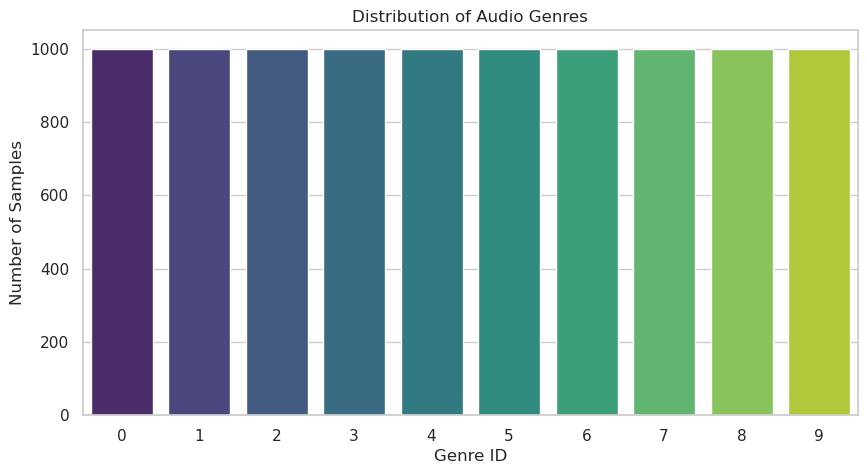

In [7]:
target_col = 'genre_id' # Change this if your label column has a different name

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x=target_col, palette='viridis')
plt.title('Distribution of Audio Genres')
plt.xlabel('Genre ID')
plt.ylabel('Number of Samples')
plt.show()

## Feature Distribution

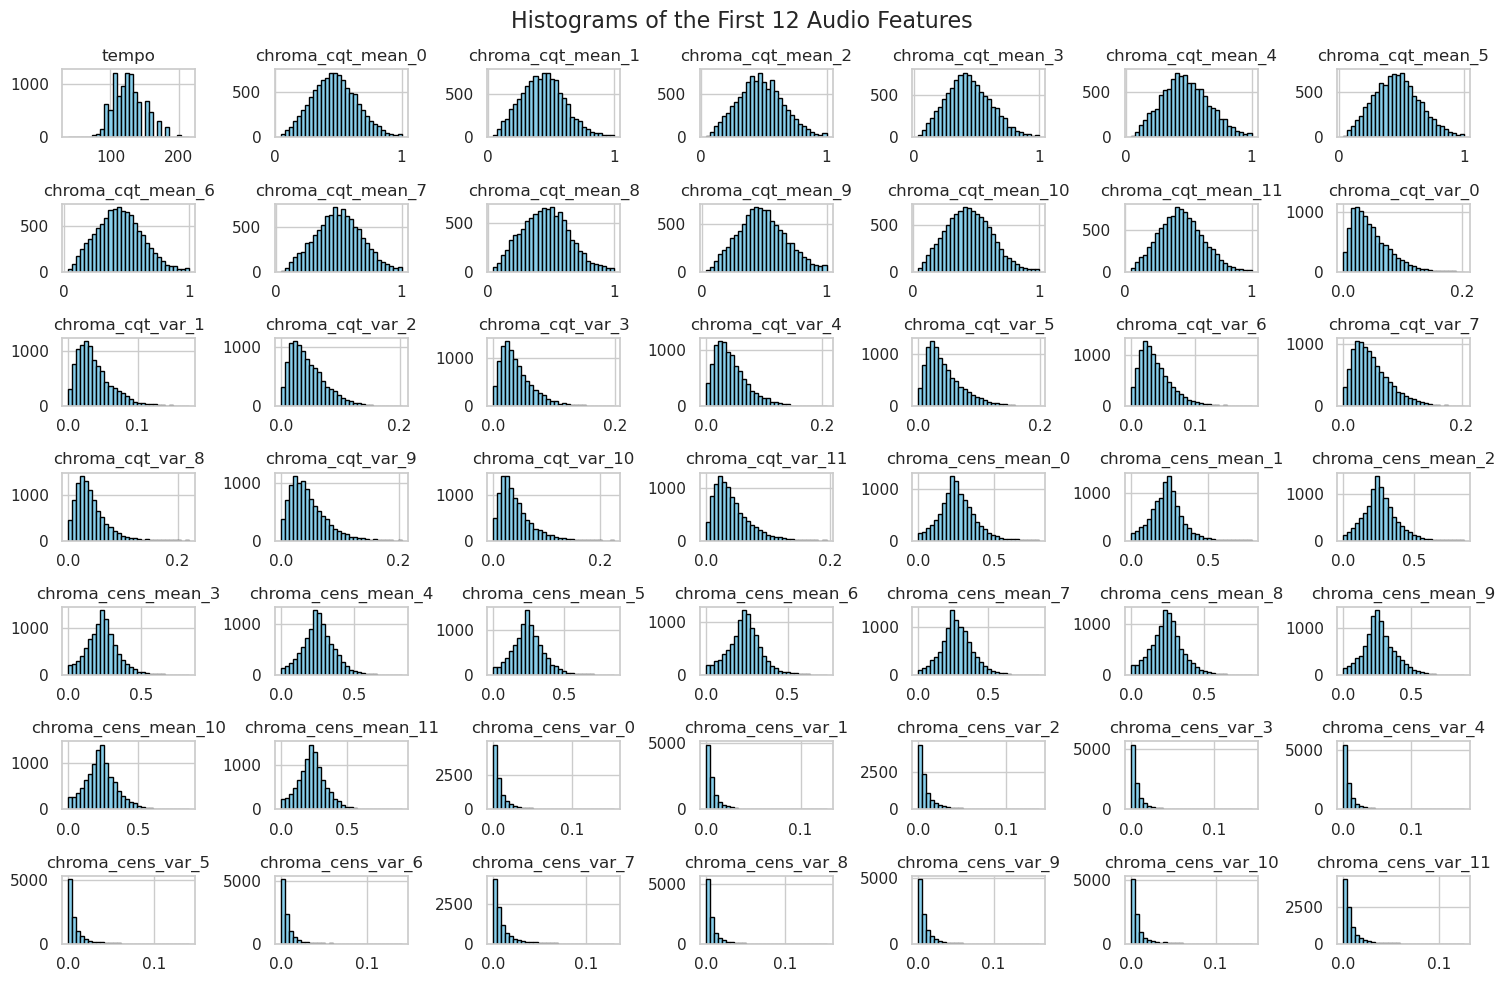

In [8]:
# Select only the numerical feature columns (exclude the target label)
feature_cols = df.drop(columns=[target_col, "Unnamed: 0.1", "Unnamed: 0", "track_id", "genre_id", "genre_name"]).select_dtypes(include=[np.number]).columns

# Safely select the first 30 features to avoid overloading the notebook output
features_to_plot = feature_cols[:49] 

df[features_to_plot].hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Histograms of the First 12 Audio Features', fontsize=16)
plt.tight_layout()
plt.show()

## Feature Correlation

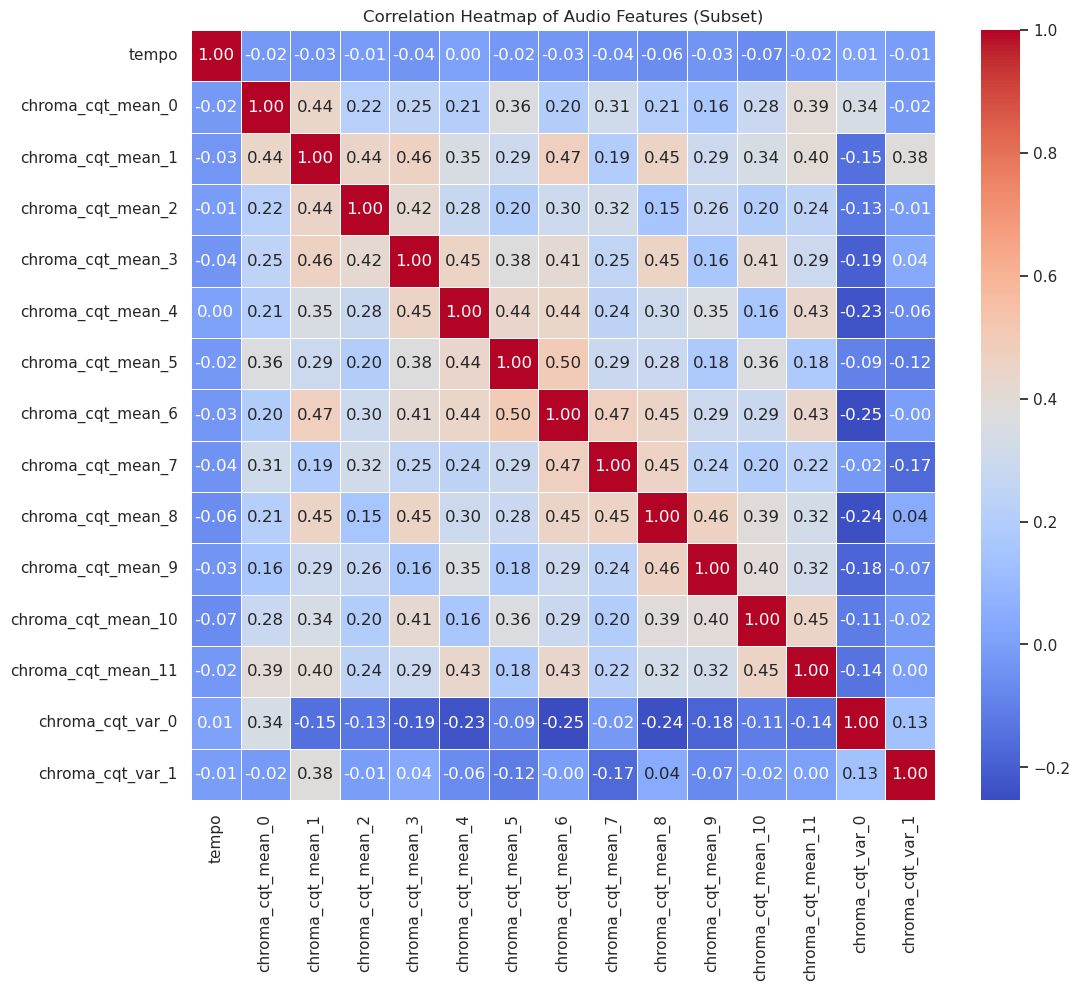

In [9]:
# Calculate the correlation matrix for a subset of features (e.g., first 15)
# Plotting a 1000x1000 correlation matrix is unreadable, so we subset
subset_features = feature_cols[:15]
corr_matrix = df[subset_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Audio Features (Subset)')
plt.show()

## Feature Correlation Box Plots

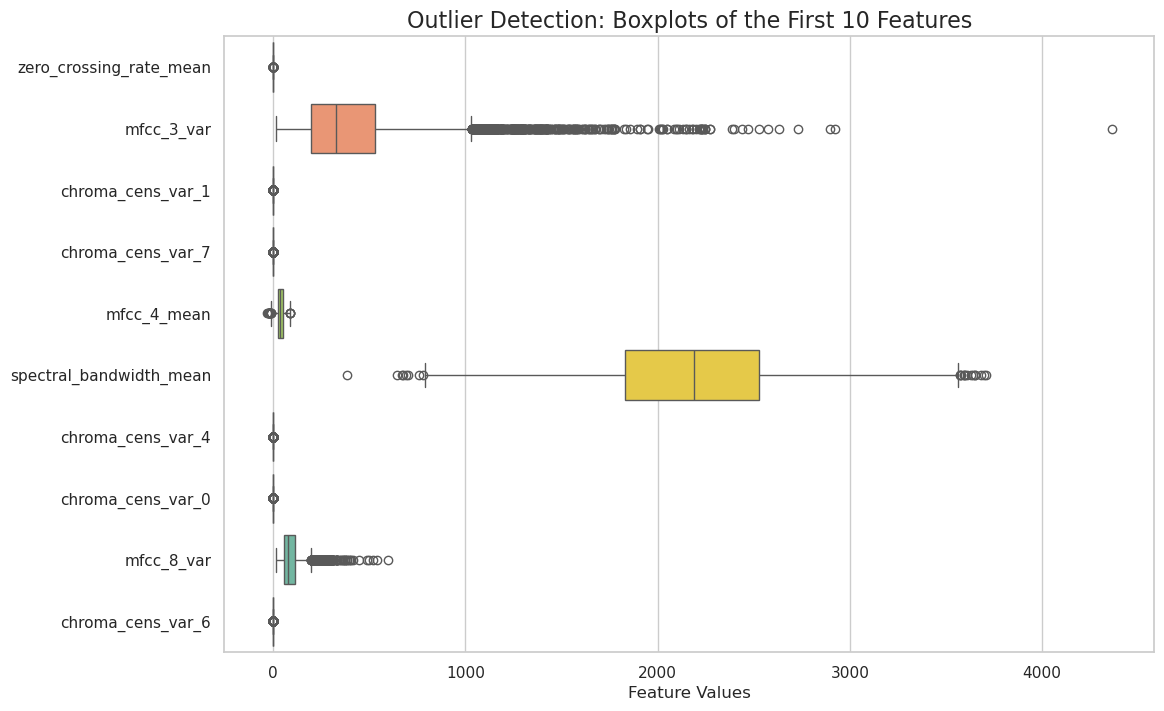

/tmp/ipykernel_11895/2278189902.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=feature_to_examine, palette="viridis")


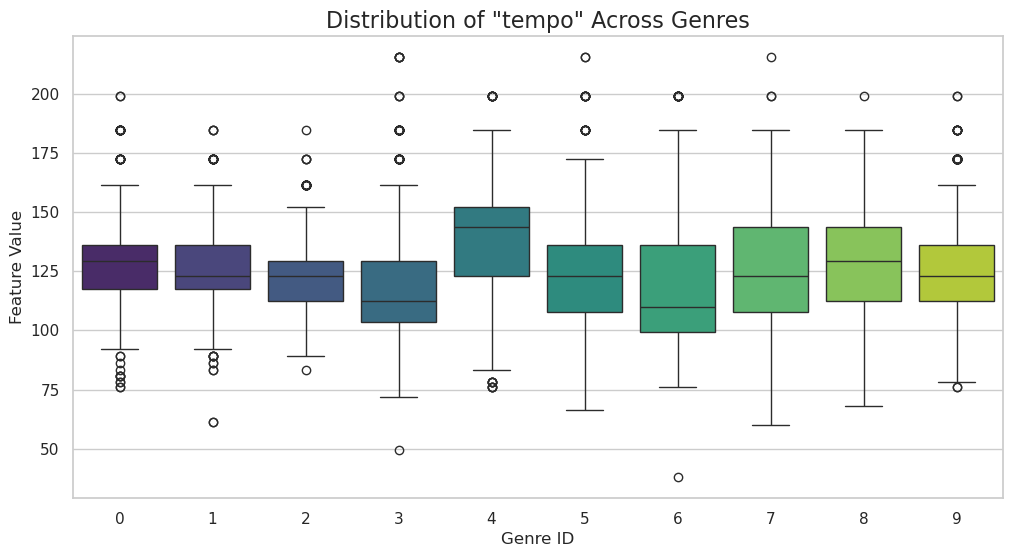

In [10]:
# --- 1. General Outlier Detection across Features ---
# Select a subset of features to keep the plot readable (e.g., the first 10)
num_features = min(10, len(feature_cols))
random_features = np.random.choice(feature_cols, size=num_features, replace=False)

plt.figure(figsize=(12, 8))
# orient="h" makes it horizontal, which is easier to read for many features
sns.boxplot(data=df[random_features], orient="h", palette="Set2")
plt.title('Outlier Detection: Boxplots of the First 10 Features', fontsize=16)
plt.xlabel('Feature Values')
plt.show()

# --- 2. Feature Distribution by Genre ---
# Let's look at how the very first feature varies across your different genres.
# (You can change feature_cols[0] to any specific column name you want to investigate)
feature_to_examine = feature_cols[0] 

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x=target_col, y=feature_to_examine, palette="viridis")
plt.title(f'Distribution of "{feature_to_examine}" Across Genres', fontsize=16)
plt.xlabel('Genre ID')
plt.ylabel('Feature Value')
plt.show()

## Model Tests + Evaluation

## Evaluation Function

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Import the models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

def evaluate_traditional_models(csv_path, target_column="genre_name"):
    # 1. Load the DataFrame
    print("Loading data...")
    df = pd.read_csv(csv_path)
    
    # Separate features (X) and labels (y)
    X = df.drop(columns=[target_column, "Unnamed: 0.1", "Unnamed: 0", "track_id", "genre_id", "genre_name"])
    y = df[target_column]
    
    # 2. Split into train and test sets (80/20 ratio)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # 3. Scale the features (CRITICAL for KNN, SVM, Logistic Regression, and MLP)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 4. Initialize the models
    models = {
        "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
        "Support Vector Machine": SVC(max_iter=-1, kernel='rbf', random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
        "Multilayer Perceptron": MLPClassifier(hidden_layer_sizes=(100,), max_iter=2000, random_state=42)
    }
    
    # Dictionary to store accuracy scores for a final comparison chart
    accuracy_scores = {}

    # 5. Train and Evaluate each model
    for name, model in models.items():
        print(f"\n{'='*50}")
        print(f"Training {name}...")
        
        # Train the model (Random Forest doesn't strict need scaling, but it doesn't hurt it)
        model.fit(X_train_scaled, y_train)
        
        # Predict on the test set
        y_pred = model.predict(X_test_scaled)
        
        # Print Classification Report (Precision, Recall, F1-Score)
        print(f"\nClassification Report for {name}:")
        report = classification_report(y_test, y_pred)
        print(report)
        
        # Save accuracy for the final bar chart
        accuracy = model.score(X_test_scaled, y_test)
        accuracy_scores[name] = accuracy
        
        # Plot Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'Confusion Matrix: {name}')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()

    # 6. Final Comparison Bar Chart
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette='viridis')
    plt.title('Model Accuracy Comparison')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.0)
    for i, v in enumerate(accuracy_scores.values()):
        plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
    plt.show()

# To run the script, just call the function with your dataset path:
# evaluate_traditional_models("path_to_your_features.csv", target_column="genre_id")

## Evalution Graphs

Loading data...

Training K-Nearest Neighbors...

Classification Report for K-Nearest Neighbors:
              precision    recall  f1-score   support

       blues       0.82      0.86      0.84       200
   classical       0.83      0.78      0.80       200
     country       0.74      0.77      0.75       200
       disco       0.76      0.93      0.83       200
      hiphop       0.89      0.94      0.91       200
        jazz       0.84      0.76      0.80       200
       metal       0.93      0.93      0.93       200
         pop       0.91      0.81      0.86       200
      reggae       0.90      0.88      0.89       200
        rock       0.78      0.71      0.74       200

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



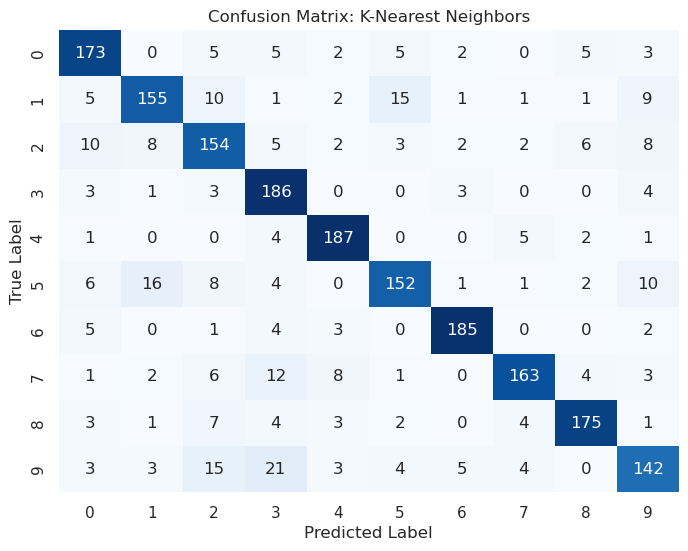


Training Support Vector Machine...

Classification Report for Support Vector Machine:
              precision    recall  f1-score   support

       blues       0.83      0.85      0.84       200
   classical       0.86      0.95      0.90       200
     country       0.82      0.77      0.79       200
       disco       0.78      0.83      0.80       200
      hiphop       0.92      0.80      0.86       200
        jazz       0.86      0.86      0.86       200
       metal       0.92      0.93      0.92       200
         pop       0.88      0.90      0.89       200
      reggae       0.84      0.88      0.86       200
        rock       0.78      0.72      0.75       200

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



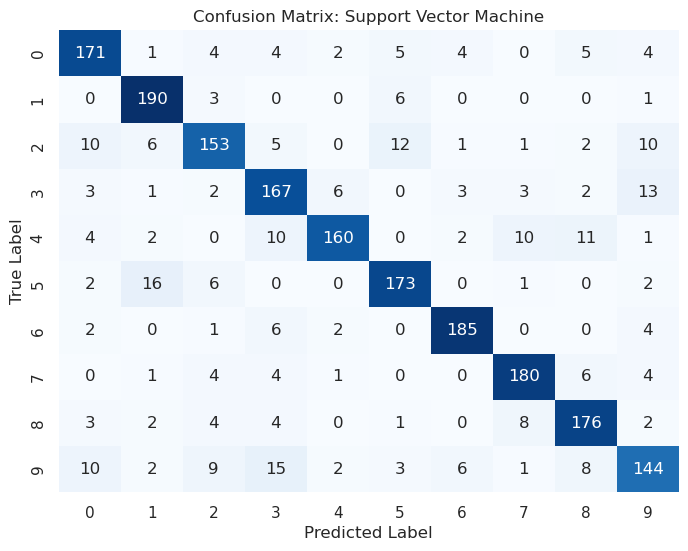


Training Random Forest...

Classification Report for Random Forest:
              precision    recall  f1-score   support

       blues       0.91      0.86      0.89       200
   classical       0.88      0.97      0.92       200
     country       0.81      0.77      0.79       200
       disco       0.82      0.85      0.84       200
      hiphop       0.92      0.85      0.88       200
        jazz       0.85      0.85      0.85       200
       metal       0.86      0.95      0.90       200
         pop       0.86      0.85      0.86       200
      reggae       0.79      0.89      0.84       200
        rock       0.83      0.70      0.76       200

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



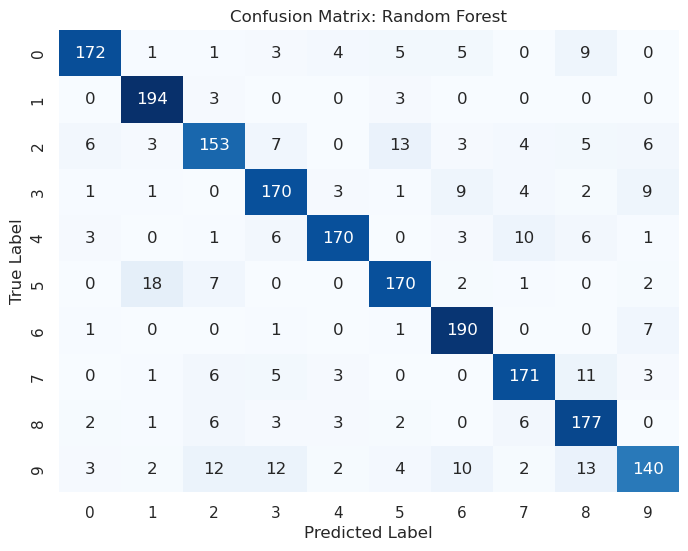


Training Logistic Regression...

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

       blues       0.73      0.69      0.71       200
   classical       0.88      0.91      0.89       200
     country       0.68      0.60      0.64       200
       disco       0.64      0.64      0.64       200
      hiphop       0.70      0.63      0.66       200
        jazz       0.77      0.80      0.78       200
       metal       0.81      0.88      0.85       200
         pop       0.75      0.85      0.79       200
      reggae       0.68      0.68      0.68       200
        rock       0.52      0.51      0.52       200

    accuracy                           0.72      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.72      0.72      0.72      2000



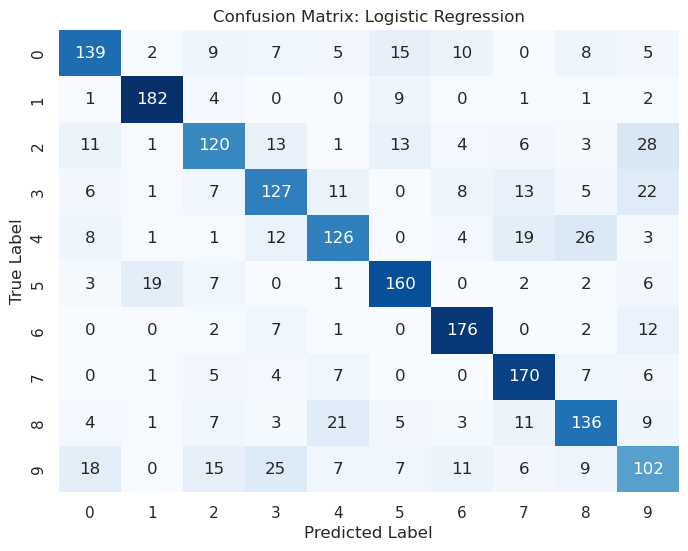


Training Multilayer Perceptron...

Classification Report for Multilayer Perceptron:
              precision    recall  f1-score   support

       blues       0.86      0.89      0.87       200
   classical       0.91      0.91      0.91       200
     country       0.84      0.79      0.81       200
       disco       0.85      0.85      0.85       200
      hiphop       0.88      0.85      0.87       200
        jazz       0.84      0.84      0.84       200
       metal       0.91      0.91      0.91       200
         pop       0.88      0.86      0.87       200
      reggae       0.82      0.86      0.84       200
        rock       0.74      0.75      0.74       200

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



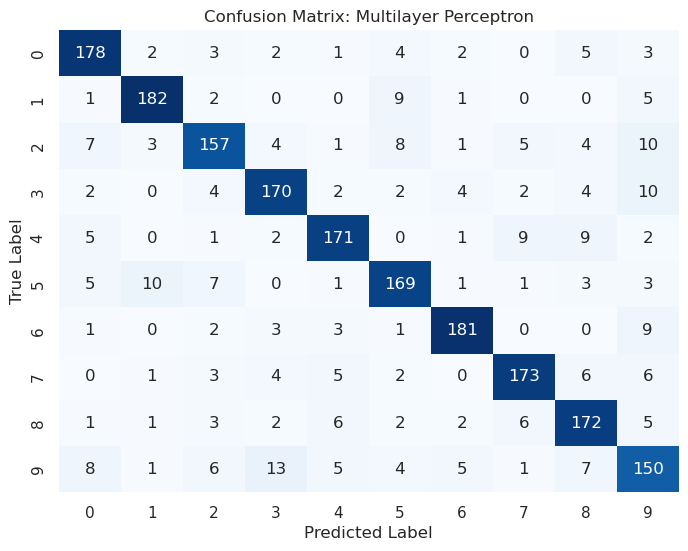

/tmp/ipykernel_11895/939753889.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette='viridis')


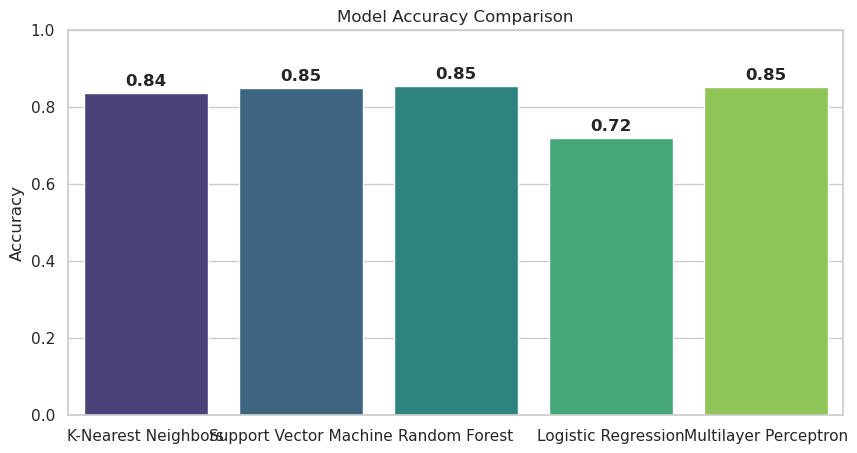

In [12]:
evaluate_traditional_models("data/features/gtzan/gtzan_3sec_features.csv", target_column="genre_name")